# Analysis of the actor database

## Import librairies

Every libraries used in this notebook.

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx

c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import datas

Import the datas from [Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata).

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

# List all files
print("Fichiers dans le dossier :")
print(os.listdir(path))

Path to dataset files: C:\Users\dav-9\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2
Fichiers dans le dossier :
['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


## Datas in pandas

Save the datas in pandas to use them in the code.

In [3]:
#  Path for movies and actors
file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# See columns
print(f"Columns in db actors : {credits.columns}")
print(f"Columns in db movie : {movies.columns}\n")

# Join both databases
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

print(f"Shape of joined database : {data.shape}\n")

print("All categories in the database :")
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])

# Check first rows
print()
print("Examples of datas")
print(data.head())

Columns in db actors : Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')
Columns in db movie : Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

Shape of joined database : (4803, 24)

All categories in the database :
['budget', 'genres', 'homepage', 'id', 'keywords']
['original_language', 'original_title', 'overview', 'popularity', 'production_companies']
['production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages']
['status', 'tagline', 'title_x', 'vote_average', 'vote_count']
['movie_id', 'title_y', 'cast', 'crew']

Examples of datas
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1 

## Clean duplicates datas

In [4]:
print(f"Nombre de lignes avant nettoyage : {len(data):,}".replace(",", " "))

data = data.drop_duplicates()

print(f"Nombre de lignes après nettoyage : {len(data):,}".replace(",", " "))

Nombre de lignes avant nettoyage : 4 803
Nombre de lignes après nettoyage : 4 803


---
## Movies repartition over the time

=== Oldest film ===
Title     : Intolerance
Date      : 1916-09-04
Budget    : $385,907
Note      : 7.4/10

=== Newest film ===
Title     : Growing Up Smith
Date      : 2017-02-03
Budget    : $0
Note      : 7.4/10


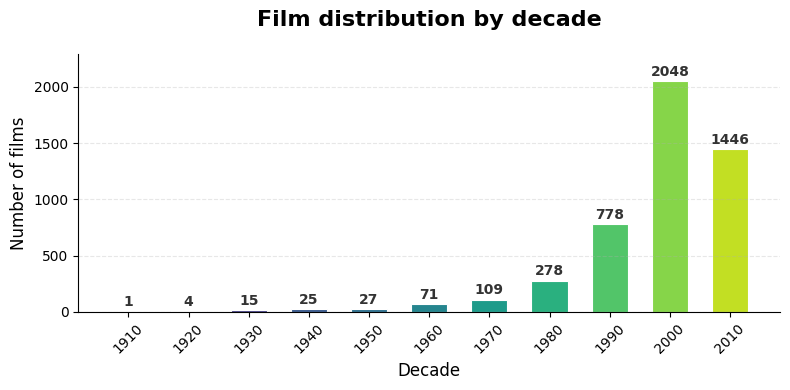

Nombre de films sans date : 1
title_x                   : America Is Still the Place
budget                    : 0
revenue                   : 0
vote_average              : 0.0
vote_count                : 0
original_language         : en
status                    : Released
overview                  : 1971 post civil rights San Francisco seemed like the perfect place for a black Korean War veteran and his family to realize their dream of economic independence and his own chance to be his a "boss". Charlie Walker would soon find out how naive he was. In a city full of impostors and naysayers, he refused to take "No" for an answer. Until a catastrophic disaster opened a door that had never been open to a black man before. This is a story about what happened when he stepped through that door, with both feet!.


In [5]:
# Convert release_date in datetime
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

# Oldest and newest films
oldest = data.loc[data['release_date'].idxmin()]
newest = data.loc[data['release_date'].idxmax()]

print("=== Oldest film ===")
print(f"Title     : {oldest['title_x']}")
print(f"Date      : {oldest['release_date'].date()}")
print(f"Budget    : ${oldest['budget']:,}")
print(f"Note      : {oldest['vote_average']}/10")

print("\n=== Newest film ===")
print(f"Title     : {newest['title_x']}")
print(f"Date      : {newest['release_date'].date()}")
print(f"Budget    : ${newest['budget']:,}")
print(f"Note      : {newest['vote_average']}/10")

# Distribution by decade
data['decade'] = (data['release_date'].dt.year // 10 * 10).astype('Int64')
decade_counts = data['decade'].value_counts().sort_index().dropna()

# Graphic to visualize
fig, ax = plt.subplots(figsize=(8, 4))

colors = plt.cm.viridis([i / len(decade_counts) for i in range(len(decade_counts))])
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values, color=colors, width=0.6, edgecolor='white', linewidth=0.8)

# Valeurs au dessus des barres
for bar, val in zip(bars, decade_counts.values) :
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

ax.set_title('Film distribution by decade', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of films', fontsize=12)
ax.set_ylim(0, decade_counts.max() * 1.12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Missing informations
print("==================")
print(f"Nombre de films sans date : {data['release_date'].isna().sum()}")

film_sans_date = data[data['release_date'].isna()].iloc[0]

# Read informations (if available)
for col in ['title_x', 'budget', 'revenue', 'vote_average', 'vote_count', 'original_language', 'status', 'overview']:
    print(f"{col:<25} : {film_sans_date[col]}")

## Number of actors

In [6]:
# All unique actors
all_actors = set()

for cast_json in data['cast'] :
    try :
        cast_list = json.loads(cast_json)
        for actor in cast_list :
            all_actors.add(actor['name'])
    except :
        pass

all_actors_filt = set()

# Filter films between 1990 and 2009
data_filtered = data[(data['release_date'].dt.year >= 1990) & (data['release_date'].dt.year <= 2009)]

for cast_json in data_filtered['cast'] :
    try :
        cast_list = json.loads(cast_json)
        for actor in cast_list :
            all_actors_filt.add(actor['name'])
    except :
        pass

print(f"Number of unique actors (all database)                  : {len(all_actors):,} ({len(all_actors)/len(all_actors)*100:.2f}%)".replace(",", " "))
print(f"Number of unique actors in movies between 1990 and 2009 : {len(all_actors_filt):,} ({len(all_actors_filt)/len(all_actors)*100:.2f}%)".replace(",", " "))

Number of unique actors (all database)                  : 54 201 (100.00%)
Number of unique actors in movies between 1990 and 2009 : 30 748 (56.73%)


## Find error in DB

There are actors that appears multiple times in the casting of a single film.

In [7]:
target_actors = ['James Caan', 'Corey Burton', 'David Lascher', 'Leo Rossi', 'Chad Donella', 
                 'Richard Linklater', 'Don Austen', 'Nick Jameson', 'Angelina Idnani']

target_actors_set = set(target_actors)

matching_films = []

for idx, row in data.iterrows():
    try :
        cast_list = json.loads(row['cast'])[:11]
        actors_in_film = {actor['name'] for actor in cast_list}
        
        found_actors = target_actors_set & actors_in_film
        
        if found_actors :
            matching_films.append({
                'title': row.get('title', 'Unknown'),
                'release_date': row.get('release_date', 'Unknown'),
                'found_actors': found_actors,
                'cast_json': cast_list})
    except :
        pass

print(f"Nombre de films trouvés : {len(matching_films)}\n")

film_with_error = []
for film in matching_films :
    #print(f"{film['title']} ({film['release_date']})")
    #print(f"\tActeur trouvé : {', '.join(film['found_actors'])}")
    #print(f"\tCast :")
    list_act = []
    for member in film['cast_json'][:11] :
        name = member['name']
        if name not in list_act :
            list_act.append(name)
        else :
            film_with_error.append(film) 
        #print(f"      - {member['name']}")
    #print()

print(f"Nombre de films avec erreur : {len(film_with_error)}\n")

for film in film_with_error :
    print(f"{film['title']} ({film['release_date']})")
    print(f"\tActeur trouvé : {', '.join(film['found_actors'])}")
    print(f"\tCast :")
    for member in film['cast_json'][:11] :
        print(f"      - {member}")
    print()


print(film_with_error[2])
print()
print(film_with_error[3])

Nombre de films trouvés : 38

Nombre de films avec erreur : 10

Unknown (1996-02-02 00:00:00)
	Acteur trouvé : David Lascher
	Cast :
      - {'cast_id': 1, 'character': "Captain Christopher 'Skipper' Sheldon", 'credit_id': '52fe43829251416c75013243', 'gender': 2, 'id': 1229, 'name': 'Jeff Bridges', 'order': 0}
      - {'cast_id': 2, 'character': 'Dr. Alice Sheldon', 'credit_id': '52fe43829251416c75013247', 'gender': 1, 'id': 6692, 'name': 'Caroline Goodall', 'order': 1}
      - {'cast_id': 3, 'character': 'McCrea, Albatross Crewman', 'credit_id': '52fe43829251416c7501324b', 'gender': 2, 'id': 47879, 'name': 'John Savage', 'order': 2}
      - {'cast_id': 4, 'character': "Charles 'Chuck' Gieg", 'credit_id': '52fe43829251416c7501324f', 'gender': 2, 'id': 24965, 'name': 'Scott Wolf', 'order': 3}
      - {'cast_id': 5, 'character': 'Frank Beaumont', 'credit_id': '52fe43829251416c75013253', 'gender': 2, 'id': 23958, 'name': 'Jeremy Sisto', 'order': 4}
      - {'cast_id': 6, 'character': 'Gil

---
## Extract Actors and create graph

We can vary the number of actor to extract from films (always taking the X most important actors).

We create a graph with all actors extracted (link between actors if they played in the same film).

In [8]:
# Extract nbr most important actors from cast_json
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        
        # List of actor's names
        top = [actor['name'] for actor in cast_list]

        # Fill up the list with "None" if not enough
        while len(top) < nbr :
            top.append(None)

        return top[:nbr]
    
    # List of "None" if error
    except :
        return [None] * nbr

# Extract "nbr_actors" actors from movies between "firstyear" and "lastyear" 
# Can be filtered by genre and note too
# Return the graph of actors
def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filter genre
    if genre is not None :
        df = df[df['genres'].str.contains(genre, na=False)]

    # release_date in datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    # Extract year
    df['release_year'] = df['release_date'].dt.year

    # Filter score and year (included)
    df = df[(df['release_year'] >= firstyear) & (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) & (df['vote_average'] <= maxscore)]

    # Keep only useful columns
    df = df[['original_title', 'cast', 'release_year']]

    # New column 'actors' with the list of actors extracted
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Graph creation
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Filter "None" values
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Link between actors
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

### Graph statistics based on the number of actors extracted

In [9]:
stats = []

for nb_actor in range(3, 11) : 
    # Graph with "nb_actor" actors extracted in movies between 1990 and 2009
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    stats.append({'nb_actor'  : nb_actor,
                    'acteurs'   : G.number_of_nodes(),
                    'collabs'   : G.number_of_edges()})

    print(f"Graphical statistics keeping the first {nb_actor} actors : ")
    print(f"\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
    print(f"\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))
    print()

Graphical statistics keeping the first 3 actors : 
	Number of actors : 3 455
	Number of links  : 8 119

Graphical statistics keeping the first 4 actors : 
	Number of actors : 4 569
	Number of links  : 16 184

Graphical statistics keeping the first 5 actors : 
	Number of actors : 5 732
	Number of links  : 26 811

Graphical statistics keeping the first 6 actors : 
	Number of actors : 6 894
	Number of links  : 39 772

Graphical statistics keeping the first 7 actors : 
	Number of actors : 8 086
	Number of links  : 54 894

Graphical statistics keeping the first 8 actors : 
	Number of actors : 9 281
	Number of links  : 72 063

Graphical statistics keeping the first 9 actors : 
	Number of actors : 10 486
	Number of links  : 90 936

Graphical statistics keeping the first 10 actors : 
	Number of actors : 11 637
	Number of links  : 111 299



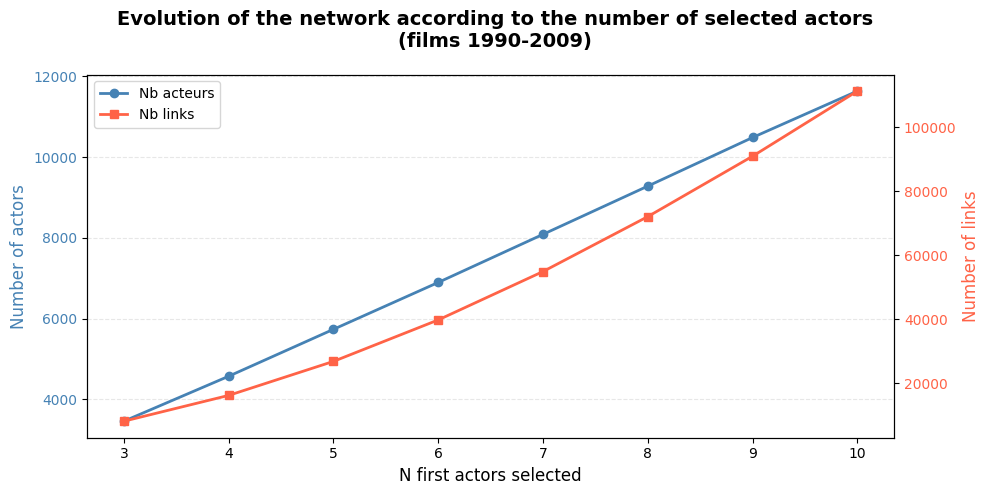

In [10]:
# Visual distribution
df_stats = pd.DataFrame(stats)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: number of actors
ax1.plot(df_stats['nb_actor'], df_stats['acteurs'], color='steelblue', marker='o', linewidth=2, label="Nb acteurs")
ax1.set_xlabel("N first actors selected", fontsize=12)
ax1.set_ylabel("Number of actors", color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Right axis: number of links
ax2 = ax1.twinx()
ax2.plot(df_stats['nb_actor'], df_stats['collabs'], 
         color='tomato', marker='s', linewidth=2, label="Nb links")
ax2.set_ylabel("Number of links", color='tomato', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tomato')

# Caption
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xticks(df_stats['nb_actor'])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
fig.suptitle("Evolution of the network according to the number of selected actors\n(films 1990-2009)", 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("Images/Actors/node_vs_links.png")
plt.show()

## Visualisation of the graph with 3 actors per movies (1990-2009)

We keep only the nodes with 20+ connections for a better visualization.

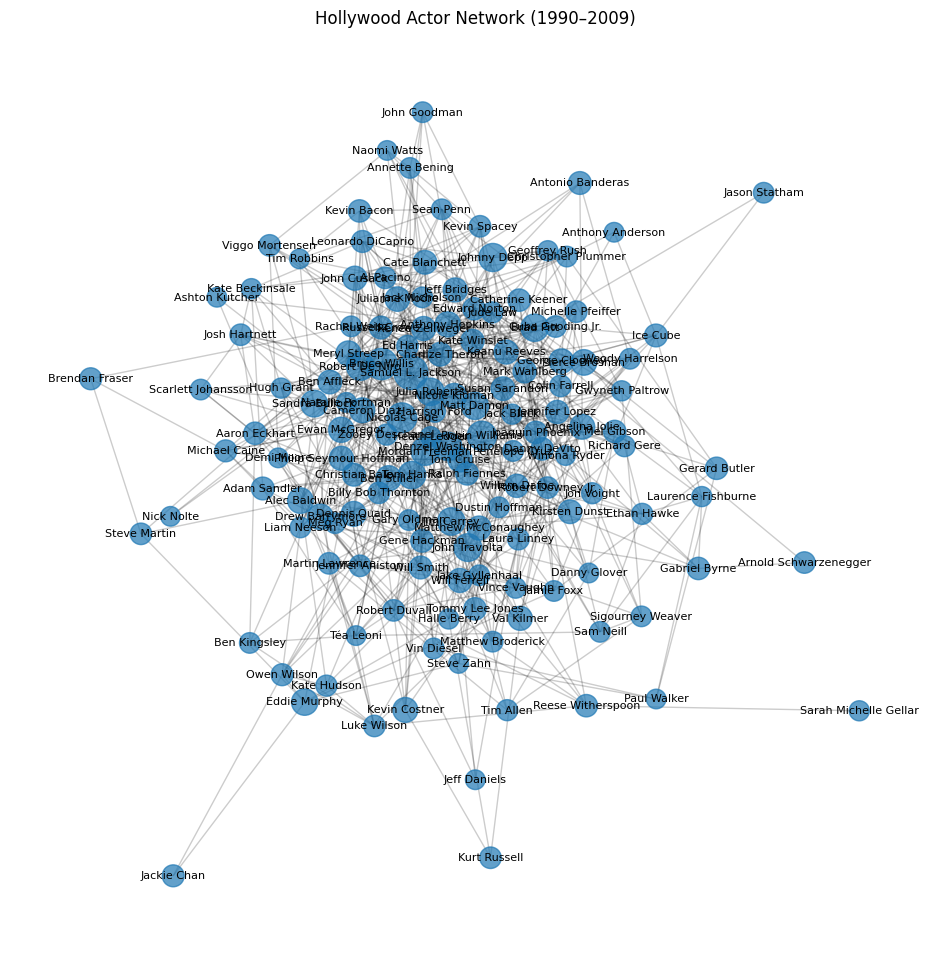

In [11]:
# Graph with 3 actors
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

# Degree (for the size)
degree_dict = dict(G.degree())

# Keep the actors with at least 20 connections (for visualization)
filtered_nodes = [node for node, deg in degree_dict.items() if deg >= 20]

subG = G.subgraph(filtered_nodes)

# Visualization of graph
plt.figure(figsize=(12,12))
pos = nx.spring_layout(subG, k=0.3)

nx.draw_networkx_nodes(subG, pos, node_size=[degree_dict[n]*10 for n in subG.nodes()], alpha=0.7)

nx.draw_networkx_edges(subG, pos, alpha=0.2)

nx.draw_networkx_labels(subG, pos, font_size=8)

plt.title("Hollywood Actor Network (1990–2009)")
plt.axis("off")
plt.savefig("Images/Actors/actor_network.png")
plt.show()

---
## Centrality of actors

Degree → nombre de co-acteurs

Betweenness → se lit comme "X% des chemins du réseau passent par cet acteur"

PageRank → rang (1 = le plus influent)

In [12]:
# For the graph with 3 most popular actors per movies
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

# Degree, betweenness, pagerank
degree_raw        = dict(G.degree())
betweenness       = nx.betweenness_centrality(G)
pagerank          = nx.pagerank(G)

df_centrality = pd.DataFrame({
    'actor'             : list(degree_raw.keys()),
    'nb_coacteurs'      : list(degree_raw.values()),                          # nombre brut
    'betweenness_pct'   : [round(betweenness[a] * 100, 2) for a in degree_raw],  # en %
    'pagerank_rank'     : [pagerank[a] for a in degree_raw]
})

# Add PageRank ordered
df_centrality['pagerank_rang'] = df_centrality['pagerank_rank'].rank(ascending=False).astype(int)
df_centrality = df_centrality.sort_values('nb_coacteurs', ascending=False)

print("=== Top 10 by degree ===")
print(df_centrality.nlargest(10, 'nb_coacteurs')[['actor', 'nb_coacteurs', 'pagerank_rang']].to_string(index=False))

print("\n=== Top 10 by betweenness ===")
print(df_centrality.nlargest(10, 'betweenness_pct')[['actor', 'betweenness_pct', 'nb_coacteurs']]
      .rename(columns={'betweenness_pct': '% chemins passant par cet acteur'}).to_string(index=False))

print("\n=== Top 10 by PageRank (rang) ===")
print(df_centrality.nsmallest(10, 'pagerank_rang')[['actor', 'pagerank_rang', 'nb_coacteurs']].to_string(index=False))

# Overall statistics for context
print(f"\n=== Network context ===")
print(f"\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))
print(f"Moyenne de co-acteurs/acteur : {sum(degree_raw.values()) / len(degree_raw):.1f}")

=== Top 10 by degree ===
            actor  nb_coacteurs  pagerank_rang
Samuel L. Jackson            60              1
     Bruce Willis            51              2
     Nicolas Cage            46              3
   Robin Williams            44              4
Denzel Washington            41              5
   Morgan Freeman            41              9
      Johnny Depp            41             12
   Robert De Niro            40             11
    John Travolta            40             13
        Brad Pitt            39             15

=== Top 10 by betweenness ===
            actor  % chemins passant par cet acteur  nb_coacteurs
Samuel L. Jackson                              2.60            60
     Bruce Willis                              2.32            51
       Matt Damon                              1.52            38
        Tom Hanks                              1.50            39
Denzel Washington                              1.35            41
   Robert De Niro              

### Varying the first n actors for actor centrality

In [13]:
# From 3 to 10 actors
for nb_actor in range(3, 11) : 
    print(f"\nFor the first {nb_actor} actors : ")
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    # Degree, betweenness, pagerank
    degree_raw        = dict(G.degree())
    betweenness       = nx.betweenness_centrality(G)
    pagerank          = nx.pagerank(G)

    df_centrality = pd.DataFrame({
        'actor'             : list(degree_raw.keys()),
        'nb_coacteurs'      : list(degree_raw.values()),                          # nombre brut
        'betweenness_pct'   : [round(betweenness[a] * 100, 2) for a in degree_raw],  # en %
        'pagerank_rank'     : [pagerank[a] for a in degree_raw]
    })

    # Add PageRank ordered
    df_centrality['pagerank_rang'] = df_centrality['pagerank_rank'].rank(ascending=False).astype(int)
    df_centrality = df_centrality.sort_values('nb_coacteurs', ascending=False)

    print("\t=== Top 3 by degree ===")
    print(f"\t{df_centrality.nlargest(3, 'nb_coacteurs')[['actor', 'nb_coacteurs', 'pagerank_rang']].to_string(index=False)}")

    print("\n\t=== Top 3 by betweenness ===")
    print(f"\t{df_centrality.nlargest(3, 'betweenness_pct')[['actor', 'betweenness_pct', 'nb_coacteurs']].rename(columns={'betweenness_pct': '% chemins passant par cet acteur'}).to_string(index=False)}")

    print("\n\t=== Top 3 by PageRank (rang) ===")
    print(f"\t{df_centrality.nsmallest(3, 'pagerank_rang')[['actor', 'pagerank_rang', 'nb_coacteurs']].to_string(index=False)}")

    # Overall statistics for context
    print(f"\n\t=== Network context ===")
    print(f"\t\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
    print(f"\t\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))
    print(f"\t\tMoyenne de co-acteurs/acteur : {sum(degree_raw.values()) / len(degree_raw):.1f}\n")


For the first 3 actors : 
	=== Top 3 by degree ===
	            actor  nb_coacteurs  pagerank_rang
Samuel L. Jackson            60              1
     Bruce Willis            51              2
     Nicolas Cage            46              3

	=== Top 3 by betweenness ===
	            actor  % chemins passant par cet acteur  nb_coacteurs
Samuel L. Jackson                              2.60            60
     Bruce Willis                              2.32            51
       Matt Damon                              1.52            38

	=== Top 3 by PageRank (rang) ===
	            actor  pagerank_rang  nb_coacteurs
Samuel L. Jackson              1            60
     Bruce Willis              2            51
     Nicolas Cage              3            46

	=== Network context ===
		Number of actors : 3 455
		Number of links  : 8 119
		Moyenne de co-acteurs/acteur : 4.7


For the first 4 actors : 
	=== Top 3 by degree ===
	            actor  nb_coacteurs  pagerank_rang
Samuel L. Jackson    

## Shortest path between two actors and small world phenomenon

A true small-world network has a short average distance and high clustering.

Clustering close to 1 = friends of my friends are also my friends

In [14]:
# For the graph with 3 most popular actors per movies
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

# displays the shortest path between actor1 and actor2 in G
def shortest_path_between(G, actor1, actor2) :
    try :
        path = nx.shortest_path(G, source=actor1, target=actor2)
        print(f"Chemin entre '{actor1}' et '{actor2}' ({len(path)-1} degrés) :")
        for i, actor in enumerate(path) :
            print(f"  {'-> ' if i > 0 else ''}{actor}")
    except nx.NetworkXNoPath :
        print(f"Aucun chemin trouvé entre '{actor1}' et '{actor2}'")
    except nx.NodeNotFound as e :
        print(f"Acteur introuvable : {e}")

# Exemple
shortest_path_between(G, "Kevin Bacon", "Tom Hanks")
shortest_path_between(G, "Brad Pitt", "Meryl Streep")

# Average distance across the entire graph
largest_cc = G.subgraph(max(nx.connected_components(G), key=len))
avg_path = nx.average_shortest_path_length(largest_cc)

# Finding the actor who is closest to everyone ("center" of the network)
closeness = nx.closeness_centrality(largest_cc)
df_closeness = pd.Series(closeness).sort_values(ascending=False)

print("=== Top 10 actors closest to the entire network ===")
for actor, score in df_closeness.head(10).items() :
    avg_distance = 1 / score  # inverse de la closeness
    print(f"{actor:<20} : average distance {avg_distance:.2f} degrees")

# Check out the small world phenomenon
print(f"\n=== Small world phenomenon ===")
print(f"Average distance       : {avg_path:.2f}")
print(f"Clustering coefficient : {nx.average_clustering(largest_cc):.4f}")

Chemin entre 'Kevin Bacon' et 'Tom Hanks' (1 degrés) :
  Kevin Bacon
  -> Tom Hanks
Chemin entre 'Brad Pitt' et 'Meryl Streep' (2 degrés) :
  Brad Pitt
  -> Kevin Bacon
  -> Meryl Streep
=== Top 10 actors closest to the entire network ===
Samuel L. Jackson    : average distance 3.14 degrees
Bruce Willis         : average distance 3.17 degrees
Julia Roberts        : average distance 3.25 degrees
Meryl Streep         : average distance 3.25 degrees
Nicolas Cage         : average distance 3.27 degrees
Robin Williams       : average distance 3.27 degrees
Cameron Diaz         : average distance 3.28 degrees
Robert De Niro       : average distance 3.28 degrees
Morgan Freeman       : average distance 3.29 degrees
John Travolta        : average distance 3.29 degrees

=== Small world phenomenon ===
Average distance       : 4.62
Clustering coefficient : 0.6207


### Varying the first n actors for shortest path between and small world phenomenon

In [15]:
avg_distances = []
clustering_coeffs = []

# From 3 to 10 actors
for nb_actor in range(3, 11) : 
    print(f"\nFor the first {nb_actor} actors : ")
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    # Average distance across the entire graph
    largest_cc = G.subgraph(max(nx.connected_components(G), key=len))
    avg_path = nx.average_shortest_path_length(largest_cc)

    # Finding the actor who is closest to everyone ("center" of the network)
    closeness = nx.closeness_centrality(largest_cc)
    df_closeness = pd.Series(closeness).sort_values(ascending=False)

    clustering = nx.average_clustering(largest_cc)
    avg_distances.append(avg_path)
    clustering_coeffs.append(clustering)

    print("\t=== Top 3 actors closest to the entire network ===")
    for actor, score in df_closeness.head(3).items():
        avg_distance = 1 / score  # inverse de la closeness
        print(f"\t{actor:<20} : average distance {avg_distance:.2f} degrees")

    # Check out the small world phenomenon
    print(f"\n\t=== Small world phenomenon ===")
    print(f"\tAverage distance       : {avg_path:.2f}")
    print(f"\tClustering coefficient : {clustering:.4f}")


For the first 3 actors : 
	=== Top 3 actors closest to the entire network ===
	Samuel L. Jackson    : average distance 3.14 degrees
	Bruce Willis         : average distance 3.17 degrees
	Julia Roberts        : average distance 3.25 degrees

	=== Small world phenomenon ===
	Average distance       : 4.62
	Clustering coefficient : 0.6207

For the first 4 actors : 
	=== Top 3 actors closest to the entire network ===
	Samuel L. Jackson    : average distance 2.96 degrees
	Robert De Niro       : average distance 2.98 degrees
	Bruce Willis         : average distance 2.98 degrees

	=== Small world phenomenon ===
	Average distance       : 4.24
	Clustering coefficient : 0.6731

For the first 5 actors : 
	=== Top 3 actors closest to the entire network ===
	Samuel L. Jackson    : average distance 2.82 degrees
	Robert De Niro       : average distance 2.84 degrees
	Bruce Willis         : average distance 2.86 degrees

	=== Small world phenomenon ===
	Average distance       : 4.01
	Clustering coeffic

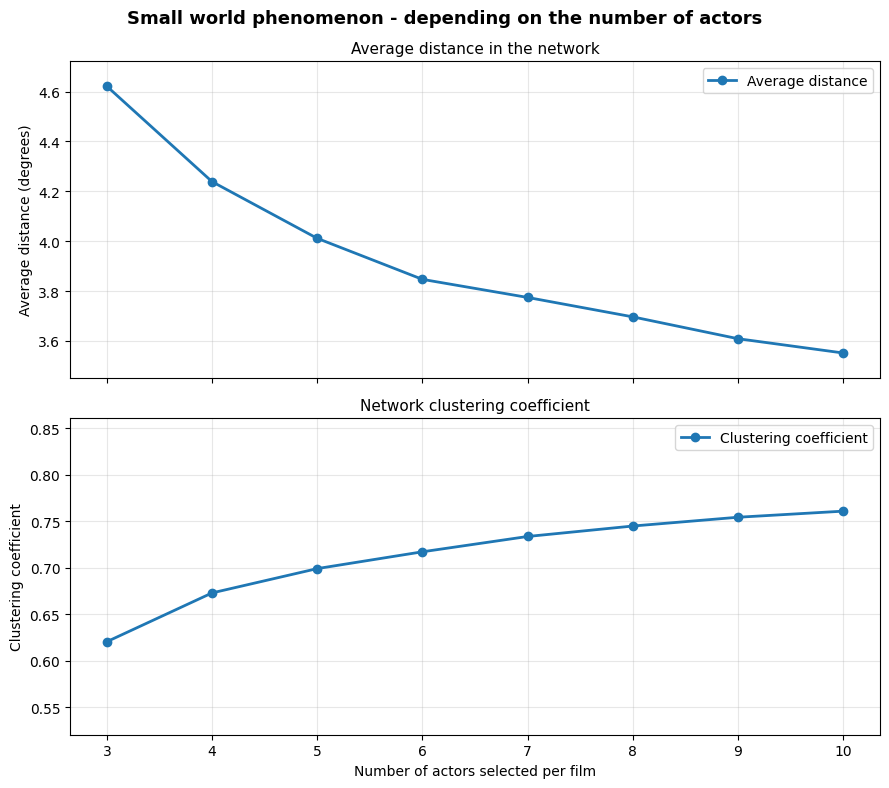

In [16]:
# Graphiques
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
fig.suptitle("Small world phenomenon - depending on the number of actors", fontsize=13, fontweight='bold')

x = list(range(3, 11))

# Average distance
margin = 0.1
ax1.set_ylim(min(avg_distances) - margin, max(avg_distances) + margin)
ax1.plot(x, avg_distances, linewidth=2, marker='o', markersize=6, label='Average distance')
ax1.set_ylabel("Average distance (degrees)")
ax1.set_title("Average distance in the network", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Clustering coefficient
ax2.set_ylim(min(clustering_coeffs) - margin, max(clustering_coeffs) + margin)
ax2.plot(x, clustering_coeffs, linewidth=2, marker='o', markersize=6, label='Clustering coefficient')
ax2.set_xlabel("Number of actors selected per film")
ax2.set_ylabel("Clustering coefficient")
ax2.set_title("Network clustering coefficient", fontsize=11)
ax2.set_xticks(x)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("Images/Actors/small_world_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

## Pairs of common actors

In [17]:
# Weighted graph to count
G_weighted = nx.Graph()

# Filter per year
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
data_filtered = data[(data['release_date'].dt.year >= 1990) & (data['release_date'].dt.year <= 2009)]

for _, row in data_filtered.iterrows() :
    try :
        # For top 3 actors
        actors = get_top_actors(row['cast'], nbr=3)
        actors = [a for a in actors if pd.notna(a)]
        for i in range(len(actors)):
            for j in range(i + 1, len(actors)):
                if G_weighted.has_edge(actors[i], actors[j]) :
                    G_weighted[actors[i]][actors[j]]['weight'] += 1
                    G_weighted[actors[i]][actors[j]]['films'].append(row['original_title'])
                else :
                    G_weighted.add_edge(actors[i], actors[j], weight=1, films=[row['original_title']])
    except :
        pass

# Extract the pairs along with their weights and films
edges_df = pd.DataFrame([{'actor1'           : u,
                            'actor2'         : v,
                            'films_ensemble' : d['weight'],
                            'films'          : d['films']}
    for u, v, d in G_weighted.edges(data=True)]).sort_values('films_ensemble', ascending=False)

print("=== Top 15 most frequent duos ===")
for _, row in edges_df.head(15).iterrows() :
    print(f"\n{row['actor1']} & {row['actor2']} ({row['films_ensemble']} films) :")
    for film in row['films'] :
        print(f"  - {film}")

=== Top 15 most frequent duos ===

Daniel Radcliffe & Rupert Grint (6 films) :
  - Harry Potter and the Half-Blood Prince
  - Harry Potter and the Order of the Phoenix
  - Harry Potter and the Goblet of Fire
  - Harry Potter and the Prisoner of Azkaban
  - Harry Potter and the Philosopher's Stone
  - Harry Potter and the Chamber of Secrets

Daniel Radcliffe & Emma Watson (6 films) :
  - Harry Potter and the Half-Blood Prince
  - Harry Potter and the Order of the Phoenix
  - Harry Potter and the Goblet of Fire
  - Harry Potter and the Prisoner of Azkaban
  - Harry Potter and the Philosopher's Stone
  - Harry Potter and the Chamber of Secrets

Rupert Grint & Emma Watson (6 films) :
  - Harry Potter and the Half-Blood Prince
  - Harry Potter and the Order of the Phoenix
  - Harry Potter and the Goblet of Fire
  - Harry Potter and the Prisoner of Azkaban
  - Harry Potter and the Philosopher's Stone
  - Harry Potter and the Chamber of Secrets

Patrick Stewart & Jonathan Frakes (4 films) :
 

### Varying the first n actors for the pairs of common actors

In [18]:
# From 3 to 10 actors
for nb_actor in range(3, 11) : 
    print(f"\nFor the first {nb_actor} actors : ")
    G_weighted = nx.Graph()

    # Filter per year
    data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
    data_filtered = data[
        (data['release_date'].dt.year >= 1990) &
        (data['release_date'].dt.year <= 2009)
    ]

    for _, row in data_filtered.iterrows() :
        try :
            actors = get_top_actors(row['cast'], nbr=nb_actor)
            actors = [a for a in actors if pd.notna(a)]
            for i in range(len(actors)):
                for j in range(i + 1, len(actors)):
                    if G_weighted.has_edge(actors[i], actors[j]) :
                        G_weighted[actors[i]][actors[j]]['weight'] += 1
                        G_weighted[actors[i]][actors[j]]['films'].append(row['original_title'])
                    else :
                        G_weighted.add_edge(actors[i], actors[j], weight=1, films=[row['original_title']])
        except :
            pass

    # Extract the pairs along with their weights and films
    edges_df = pd.DataFrame([{'actor1'           : u,
                                'actor2'         : v,
                                'films_ensemble' : d['weight'],
                                'films'          : d['films']}
        for u, v, d in G_weighted.edges(data=True)]).sort_values('films_ensemble', ascending=False)

    print("\n\t=== Top 3 most frequent duos ===")
    for _, row in edges_df.head(3).iterrows():
        print(f"\t{row['actor1']} & {row['actor2']} ({row['films_ensemble']} films) ")


For the first 3 actors : 

	=== Top 3 most frequent duos ===
	Daniel Radcliffe & Rupert Grint (6 films) 
	Daniel Radcliffe & Emma Watson (6 films) 
	Rupert Grint & Emma Watson (6 films) 

For the first 4 actors : 

	=== Top 3 most frequent duos ===
	Rupert Grint & Emma Watson (6 films) 
	Daniel Radcliffe & Rupert Grint (6 films) 
	Daniel Radcliffe & Emma Watson (6 films) 

For the first 5 actors : 

	=== Top 3 most frequent duos ===
	Daniel Radcliffe & Rupert Grint (6 films) 
	Daniel Radcliffe & Emma Watson (6 films) 
	Rupert Grint & Emma Watson (6 films) 

For the first 6 actors : 

	=== Top 3 most frequent duos ===
	Daniel Radcliffe & Rupert Grint (6 films) 
	Daniel Radcliffe & Emma Watson (6 films) 
	Rupert Grint & Emma Watson (6 films) 

For the first 7 actors : 

	=== Top 3 most frequent duos ===
	Daniel Radcliffe & Emma Watson (6 films) 
	Daniel Radcliffe & Rupert Grint (6 films) 
	Rupert Grint & Emma Watson (6 films) 

For the first 8 actors : 

	=== Top 3 most frequent duos ==

## Evolution of the network over time

In [19]:
decades = range(1960, 2020, 10)  # from 1960 to 2010

stats = []
for decade in decades :
    G_decade = get_imdb_graph(data, nbr_actors=3, firstyear=decade, lastyear=decade+9)
    
    if G_decade.number_of_nodes() == 0 :
        continue
    
    largest_cc = G_decade.subgraph(max(nx.connected_components(G_decade), key=len))
    
    stats.append({'decade'        : decade,
                    'nb_acteurs'    : G_decade.number_of_nodes(),
                    'nb_liens'      : G_decade.number_of_edges(),
                    'densite'       : round(nx.density(G_decade), 4), # to what extent the actors are interconnected in the graph
                    'composante_principale' : largest_cc.number_of_nodes()}) # largest group of actors all connected to each other

df_evolution = pd.DataFrame(stats)
print(df_evolution.to_string(index=False))

 decade  nb_acteurs  nb_liens  densite  composante_principale
   1960         182       213   0.0129                     17
   1970         264       325   0.0094                     56
   1980         633       807   0.0040                    228
   1990        1238      2294   0.0030                    939
   2000        2835      5889   0.0015                   1962
   2010        2389      4139   0.0015                   1425


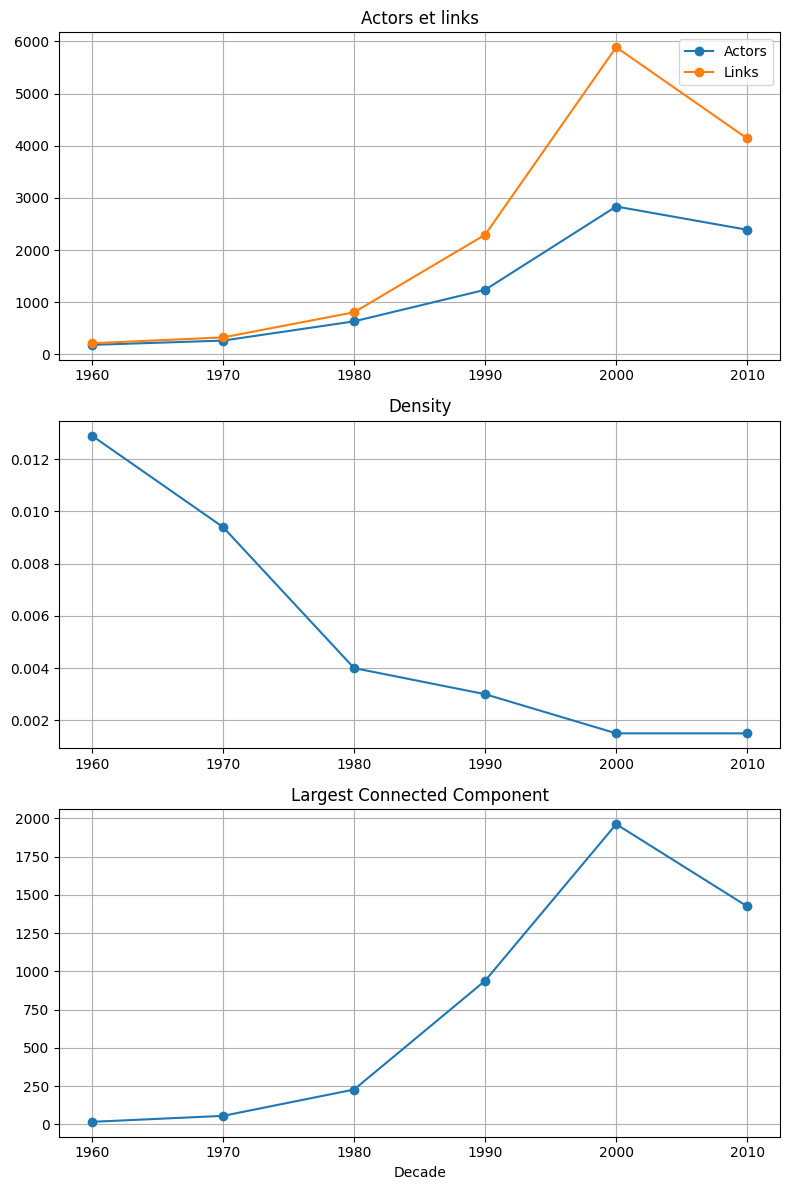

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Actors and links
axes[0].plot(df_evolution['decade'], df_evolution['nb_acteurs'], marker='o', label='Actors')
axes[0].plot(df_evolution['decade'], df_evolution['nb_liens'], marker='o', label='Links')
axes[0].set_title("Actors et links")
axes[0].legend()
axes[0].grid()

# Density
axes[1].plot(df_evolution['decade'], df_evolution['densite'], marker='o')
axes[1].set_title("Density")
axes[1].grid()

# Largest Connected Component
axes[2].plot(df_evolution['decade'], df_evolution['composante_principale'], marker='o')
axes[2].set_title("Largest Connected Component")
axes[2].grid()

plt.xlabel("Decade")
plt.tight_layout()
#plt.savefig("Images/Actors/evolution_over_decade.png")
plt.show()